## 正态分布（高斯分布）
概率密度函数：$$ f(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \cdot e^{-\frac{(x-\mu)^2}{2\sigma^2}} \quad \mu, \sigma > 0$$

## 泊松分布
一句话：用来描述 “单位时间 / 空间内，随机独立事件发生次数” 的概率分布。

$$ f(x) = \frac{\lambda^x e^{-\lambda}}{x!} \quad \lambda > 0 $$

## 卡方分布
概率质量函数：$$ f(x) = \frac{1}{2^k k!} \cdot x^k e^{-x} \quad x \ge 0 $$

## Beta 分布
概率质量函数：$$ f(x) = \frac{x^{\alpha - 1} (1 - x)^{\beta - 1}}{B(\alpha, \beta)} \quad x \in [0, 1] $$

累积分布函数(CDF)

概率密度函数(PDF)

概率质量函数(PMF)

In [19]:
import numpy as np
from scipy.stats import norm

z_values = np.array([0, 1, 2,3])
# 累积分布函数（CDF）
probs = norm.cdf(z_values)
for z, prob in zip(z_values, probs):
    print(f"P(Z ≤ {z}) = {prob:.4f}")


print(f"P( -1.0 <= Z <= 1.0) = {norm.cdf(1.0) - norm.cdf(-1.0):.4f}")
print(f"P( -2.0 <= Z <= 2.0) = {norm.cdf(2.0) - norm.cdf(-2.0):.4f}")
print(f"P( -3.0 <= Z <= 3.0) = {norm.cdf(3.0) - norm.cdf(-3.0):.4f}")


P(Z ≤ 0) = 0.5000
P(Z ≤ 1) = 0.8413
P(Z ≤ 2) = 0.9772
P(Z ≤ 3) = 0.9987
P( -1.0 <= Z <= 1.0) = 0.6827
P( -2.0 <= Z <= 2.0) = 0.9545
P( -3.0 <= Z <= 3.0) = 0.9973


<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
C:\Users\huang\AppData\Local\Temp\ipykernel_14280\3630975786.py:25: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title('标准正态分布 $X \sim \mathcal{N}(0, 1)$', fontsize=14, pad=20)


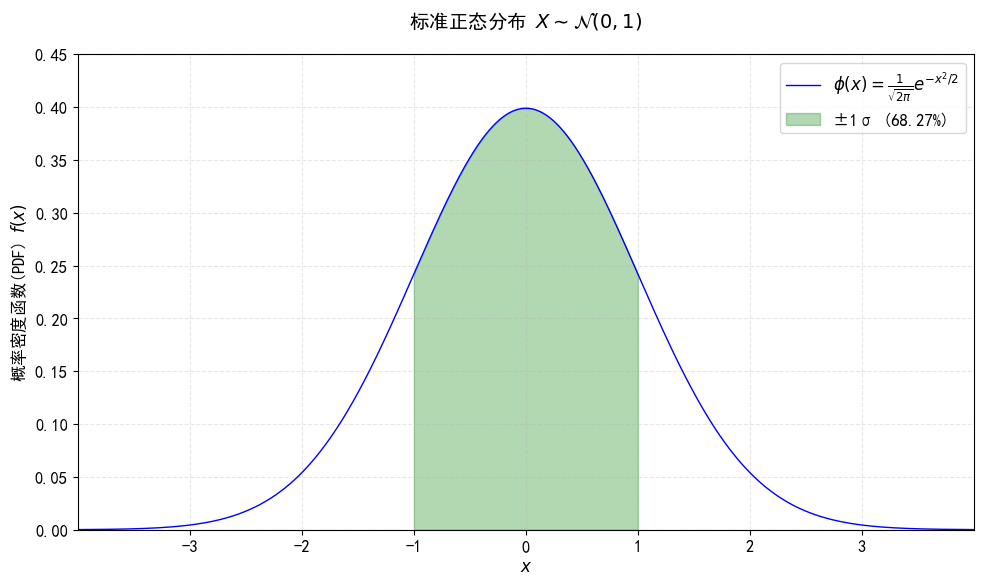

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 全局配置
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.rcParams['font.size'] = 12                # 设置默认字体大小

# 创建图形
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-4, 4, 1000)

pdf = norm.pdf(x)

# 绘制曲线
ax.plot(x, pdf, 'b-', linewidth=1, label=r'$\phi(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$')

# 填充±1, ±2, ±3标准差区域
x_fill_1 = np.linspace(-1, 1, 100)
ax.fill_between(x_fill_1, norm.pdf(x_fill_1), alpha=0.3, color='green', label='±1σ (68.27%)')

# 设置标题和标签
ax.set_title('标准正态分布 $X \sim \mathcal{N}(0, 1)$', fontsize=14, pad=20)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('概率密度函数(PDF) $f(x)$', fontsize=12)

# 设置坐标轴范围
ax.set_xlim(-4, 4)
ax.set_ylim(0, 0.45)

# 添加网格
ax.grid(alpha=0.3, linestyle='--')

# 添加图例
ax.legend(loc='upper right')

# 在x轴上标记关键点
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_xticklabels(['-3', '-2', '-1', '0', '1', '2', '3'])

plt.tight_layout()
plt.show()

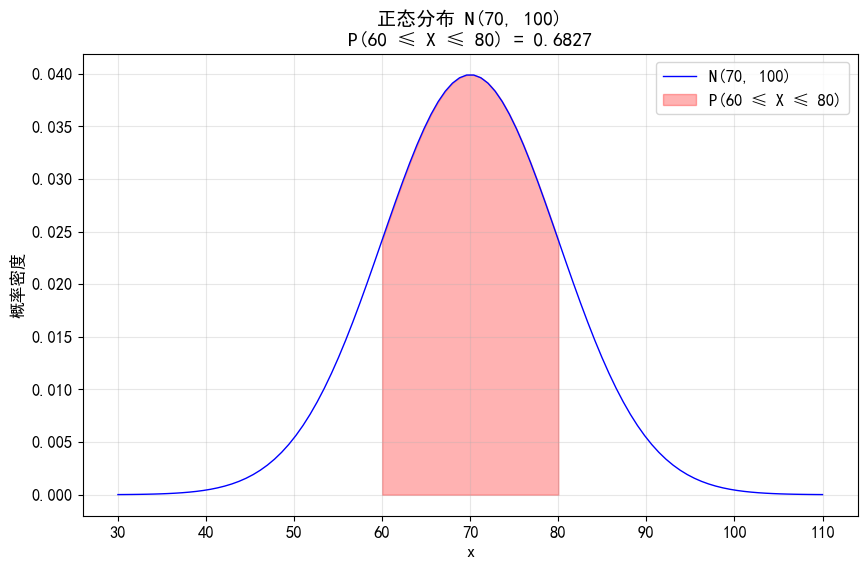

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 生成数据
mu, sigma = 70, 10
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)  # 概率密度函数

# 计算阴影区域概率
x_fill = np.linspace(60, 80, 100)
y_fill = norm.pdf(x_fill, mu, sigma)

# 绘图
plt.figure(figsize=(10, 6))
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'FangSong', 'KaiTi']
plt.plot(x, y, 'b-', linewidth=1, label=f'N({mu}, {sigma * sigma})')
plt.fill_between(x_fill, y_fill, alpha=0.3, color='red', label='P(60 ≤ X ≤ 80)')

# 计算并显示概率
prob = norm.cdf(80, mu, sigma) - norm.cdf(60, mu, sigma)
plt.title(f'正态分布 N({mu}, {sigma * sigma})\nP(60 ≤ X ≤ 80) = {prob:.4f}', fontsize=14)
plt.xlabel('x')
plt.ylabel('概率密度')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

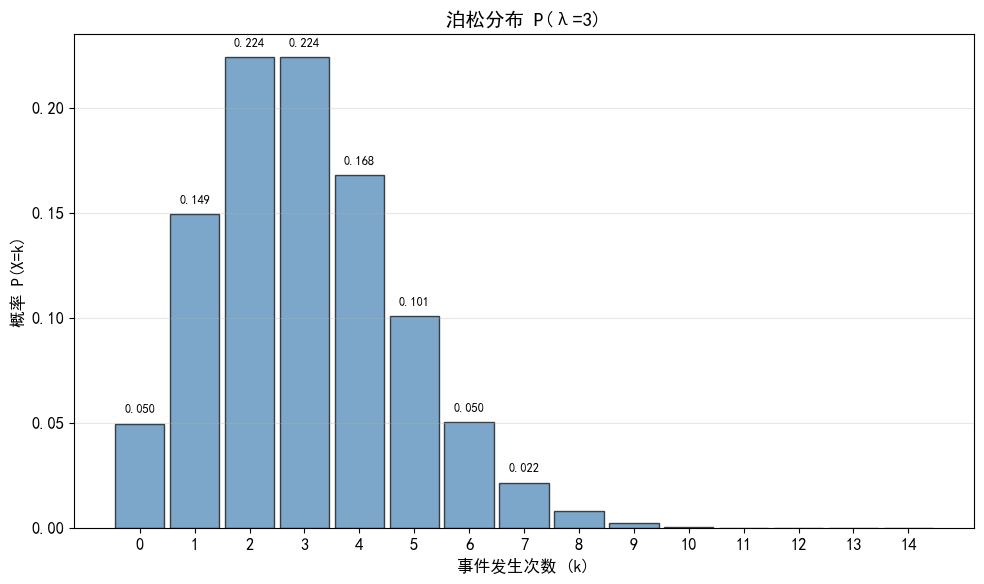

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 参数设置
lambda_val = 3  # 泊松分布参数 λ (均值)
x = np.arange(0, 15)  # 事件发生次数
pmf = poisson.pmf(x, lambda_val)  # 概率质量函数

# 绘图
plt.figure(figsize=(10, 6))
plt.bar(x, pmf, width=0.9, color='steelblue', alpha=0.7, edgecolor='black')
plt.title(f'泊松分布 P(λ={lambda_val})', fontsize=14)
plt.xlabel('事件发生次数 (k)', fontsize=12)
plt.ylabel('概率 P(X=k)', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.xticks(x)

# 添加数值标签
for i, (xi, yi) in enumerate(zip(x, pmf)):
    if yi > 0.01:
        plt.text(xi, yi + 0.005, f'{yi:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

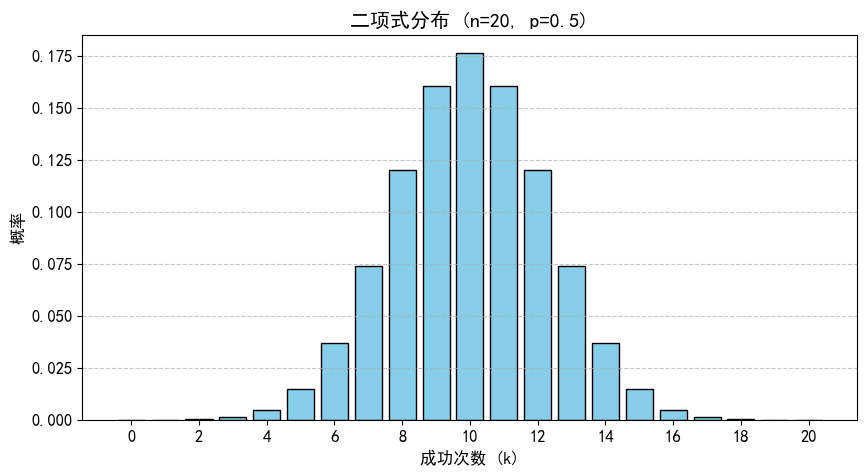

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# 参数设置
n = 20      # 试验次数
p = 0.5     # 每次试验成功的概率

# 可能的成功次数（0 到 n）
k = np.arange(0, n+1)

# 计算概率质量函数 (PMF)
pmf = binom.pmf(k, n, p)

# 绘图
plt.figure(figsize=(10, 5))
plt.bar(k, pmf, color='skyblue', edgecolor='black')
plt.xlabel('成功次数 (k)')
plt.ylabel('概率')
plt.title(f'二项式分布 (n={n}, p={p})')
plt.xticks(range(0, n+1, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

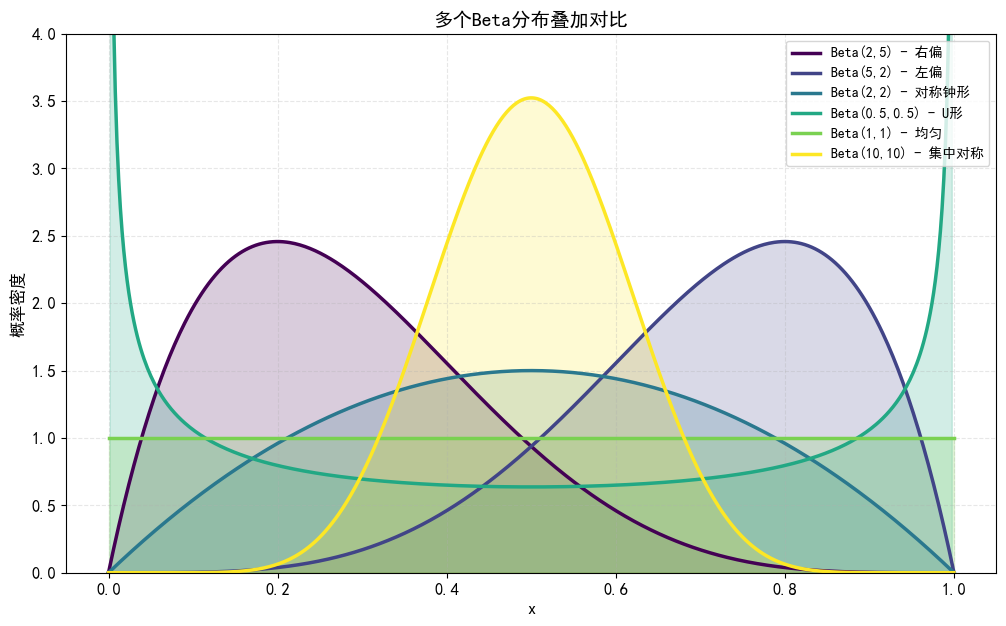

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# 定义不同的参数组合
params = [
    (2, 5, '右偏'),
    (5, 2, '左偏'),
    (2, 2, '对称钟形'),
    (0.5, 0.5, 'U形'),
    (1, 1, '均匀'),
    (10, 10, '集中对称')
]

x = np.linspace(0, 1, 500)
colors = plt.cm.viridis(np.linspace(0, 1, len(params)))

plt.figure(figsize=(12, 7))
for (a, b, label), color in zip(params, colors):
    y = beta.pdf(x, a, b)
    plt.plot(x, y, color=color, linewidth=2.5, label=f'Beta({a},{b}) - {label}')
    plt.fill_between(x, y, alpha=0.2, color=color)

plt.xlabel('x', fontsize=12)
plt.ylabel('概率密度', fontsize=12)
plt.title('多个Beta分布叠加对比', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.ylim(0, 4.0)
plt.show()

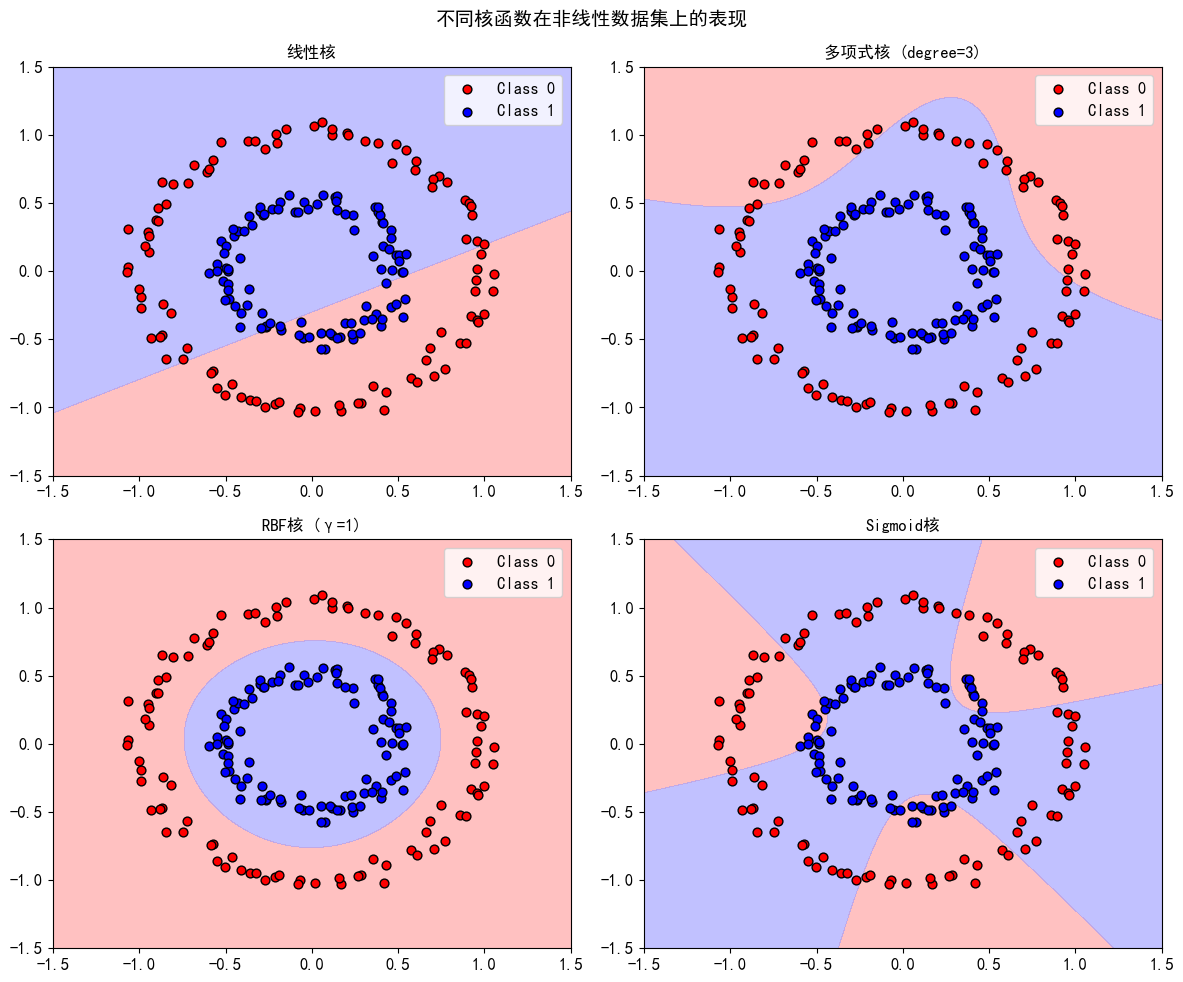

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles, make_moons

# 生成非线性数据集
X, y = make_circles(n_samples=200, factor=0.5, noise=0.05, random_state=42)

# 定义核函数
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
titles = ['线性核', '多项式核 (degree=3)', 'RBF核 (γ=1)', 'Sigmoid核']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 创建网格用于绘图
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))

for idx, (kernel, title) in enumerate(zip(kernels, titles)):
    # 训练SVM
    if kernel == 'poly':
        clf = SVC(kernel=kernel, degree=3, C=1.0)
    else:
        clf = SVC(kernel=kernel, C=1.0, gamma=1 if kernel=='rbf' else 'scale')
    clf.fit(X, y)

    # 预测网格点
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 绘制
    ax = axes[idx]
    ax.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()],
                colors=['#FF9999', '#9999FF'], alpha=0.6)
    ax.scatter(X[y==0, 0], X[y==0, 1], c='red', edgecolor='k', s=40, label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', edgecolor='k', s=40, label='Class 1')
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.legend()

plt.suptitle('不同核函数在非线性数据集上的表现', fontsize=14)
plt.tight_layout()
plt.show()